<a href="https://colab.research.google.com/github/vsindrajith7/predictive-project-grp-3/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import re
import pickle
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Download required NLTK data ──────────────────────────────────────────────
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# ── Config ────────────────────────────────────────────────────────────────────
CSV_PATH     = "emails.csv"      # path to your dataset
TEXT_COLUMN  = "text"            # column that holds email body
LABEL_COLUMN = "spam"           # column that holds spam/ham label  (spam=1, ham=0)
MAX_WORDS    = 10000             # vocabulary size for LSTM tokenizer
MAX_LEN      = 200               # max sequence length for padding
TEST_SIZE    = 0.2
RANDOM_STATE = 42

# ── 1. Load Dataset ───────────────────────────────────────────────────────────
print("Loading dataset...")
df = pd.read_csv(CSV_PATH)
print(f"  Shape : {df.shape}")
print(f"  Columns: {df.columns.tolist()}")

# Convert label to binary if needed  (spam→1, ham→0)
if df[LABEL_COLUMN].dtype == object:
    df[LABEL_COLUMN] = df[LABEL_COLUMN].map({'spam': 1, 'ham': 0})

# ── 2. Text Cleaning ──────────────────────────────────────────────────────────
lemmatizer  = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', str(text))
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower()
    # Tokenize
    tokens = text.split()
    # Remove stop words and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

print("\nCleaning email text...")
df['cleaned'] = df[TEXT_COLUMN].apply(clean_text)
print("  Done.")

# ── 3. Train / Test Split ─────────────────────────────────────────────────────
X = df['cleaned'].values
y = df[LABEL_COLUMN].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain size : {len(X_train)}")
print(f"Test  size : {len(X_test)}")

# ── 4. TF-IDF Features  (for SVM) ────────────────────────────────────────────
print("\nBuilding TF-IDF features...")
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"  TF-IDF shape (train): {X_train_tfidf.shape}")

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("  Saved: tfidf_vectorizer.pkl")

# ── 5. Padded Sequences  (for LSTM) ──────────────────────────────────────────
print("\nBuilding word sequences for LSTM...")
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post')
print(f"  Sequence shape (train): {X_train_seq.shape}")

# Save LSTM tokenizer
with open('lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("  Saved: lstm_tokenizer.pkl")

# ── 6. Save Splits ────────────────────────────────────────────────────────────
np.save('X_train_tfidf.npy', X_train_tfidf.toarray())
np.save('X_test_tfidf.npy',  X_test_tfidf.toarray())
np.save('X_train_seq.npy',   X_train_seq)
np.save('X_test_seq.npy',    X_test_seq)
np.save('y_train.npy',       y_train)
np.save('y_test.npy',        y_test)
print("\nAll features saved. Preprocessing complete! ✅")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Loading dataset...
  Shape : (5728, 2)
  Columns: ['text', 'spam']

Cleaning email text...
  Done.

Train size : 4582
Test  size : 1146

Building TF-IDF features...
  TF-IDF shape (train): (4582, 10000)
  Saved: tfidf_vectorizer.pkl

Building word sequences for LSTM...
  Sequence shape (train): (4582, 200)
  Saved: lstm_tokenizer.pkl

All features saved. Preprocessing complete! ✅


**SVM**

In [6]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

Load Preprocessed Data

In [5]:
print("Loading TF-IDF features...")
X_train = np.load('X_train_tfidf.npy')
X_test  = np.load('X_test_tfidf.npy')
y_train = np.load('y_train.npy')
y_test  = np.load('y_test.npy')
print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")

Loading TF-IDF features...
  Train: (4582, 10000)  |  Test: (1146, 10000)


Train SVM Model

In [7]:
print("\nTraining SVM (LinearSVC)...")
svm_model = LinearSVC(C=1.0, max_iter=1000)
svm_model.fit(X_train, y_train)
print("  Training complete.")



Training SVM (LinearSVC)...
  Training complete.


Predict

In [8]:
y_pred = svm_model.predict(X_test)


Evaluation

In [10]:
accuracy = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)

print("\n========== SVM Results ==========")
print(f"  Accuracy : {accuracy * 100:.2f}%")
print(f"  F1-Score : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


========== SVM Results ==========
  Accuracy : 98.95%
  F1-Score : 0.9779

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       872
        Spam       0.99      0.97      0.98       274

    accuracy                           0.99      1146
   macro avg       0.99      0.98      0.99      1146
weighted avg       0.99      0.99      0.99      1146



Confusion Matrix Plot

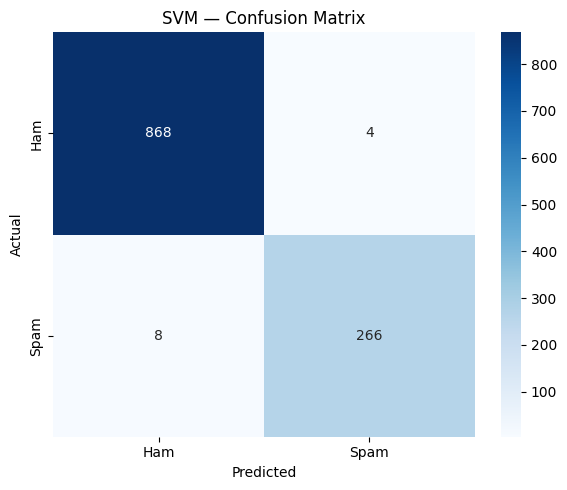


  Saved: svm_confusion_matrix.png


In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('SVM — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png')
plt.show()
print("\n  Saved: svm_confusion_matrix.png")

Save Model

In [14]:
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
print("  Saved: svm_model.pkl ✅")

  Saved: svm_model.pkl ✅


LSTM

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    roc_auc_score,
    roc_curve
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [21]:
MAX_WORDS  = 10000    # must match preprocessing.py
MAX_LEN    = 200      # must match preprocessing.py
EMBED_DIM  = 128
EPOCHS     = 10
BATCH_SIZE = 64

Load Preprocessed Data

In [22]:
print("Loading padded sequences...")
X_train = np.load('X_train_seq.npy')
X_test  = np.load('X_test_seq.npy')
y_train = np.load('y_train.npy')
y_test  = np.load('y_test.npy')
print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")

Loading padded sequences...
  Train: (4582, 200)  |  Test: (1146, 200)


Build LSTM Model

In [24]:
print("\nBuilding LSTM model...")
model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()



Building LSTM model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train

In [28]:
print("\nTraining LSTM model...")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop]
)
print("  Training complete.")


Training LSTM model...
Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 65s 886ms/step - accuracy: 0.7604 - loss: 0.5663 - val_accuracy: 0.7342 - val_loss: 0.5781
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 55s 855ms/step - accuracy: 0.7788 - loss: 0.5000 - val_accuracy: 0.7538 - val_loss: 0.4911
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 56s 864ms/step - accuracy: 0.8867 - loss: 0.2624 - val_accuracy: 0.9107 - val_loss: 0.2073
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 55s 851ms/step - accuracy: 0.8394 - loss: 0.4543 - val_accuracy: 0.7516 - val_loss: 0.5640
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 82s 836ms/step - accuracy: 0.7878 - loss: 0.5138 - val_accuracy: 0.7538 - val_loss: 0.4477
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 55s 836ms/step - accuracy: 0.8644 - loss: 0.3366 - val_accuracy: 0.9455 - val_loss: 0.1922
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 54s 830ms/step - accuracy: 0.9629 - loss: 0.1552 - val_accuracy: 0.9390 - val_loss: 0.2239
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 54s 831ms/step - accuracy: 0.9614 -

Predict

In [29]:
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)


36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 187ms/step


Evaluation

In [31]:
accuracy = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_prob)

print("\n========== LSTM Results ==========")
print(f"  Accuracy : {accuracy * 100:.2f}%")
print(f"  F1-Score : {f1:.4f}")
print(f"  ROC-AUC  : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


========== LSTM Results ==========
  Accuracy : 94.76%
  F1-Score : 0.8940
  ROC-AUC  : 0.9479

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.96      0.97       872
        Spam       0.87      0.92      0.89       274

    accuracy                           0.95      1146
   macro avg       0.92      0.94      0.93      1146
weighted avg       0.95      0.95      0.95      1146



Confusion Matrix Plot

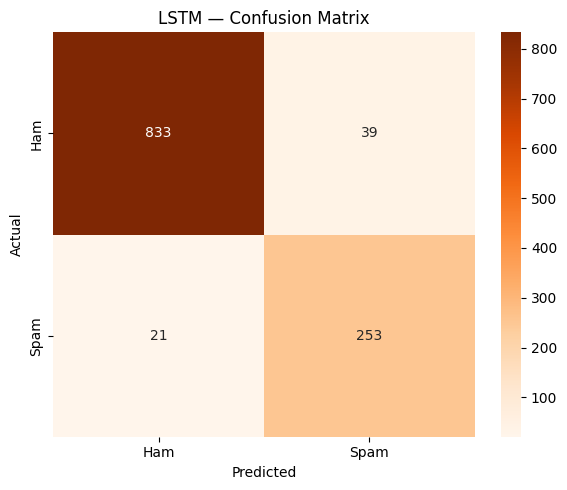

  Saved: lstm_confusion_matrix.png


In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('LSTM — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png')
plt.show()
print("  Saved: lstm_confusion_matrix.png")

Training History Plot

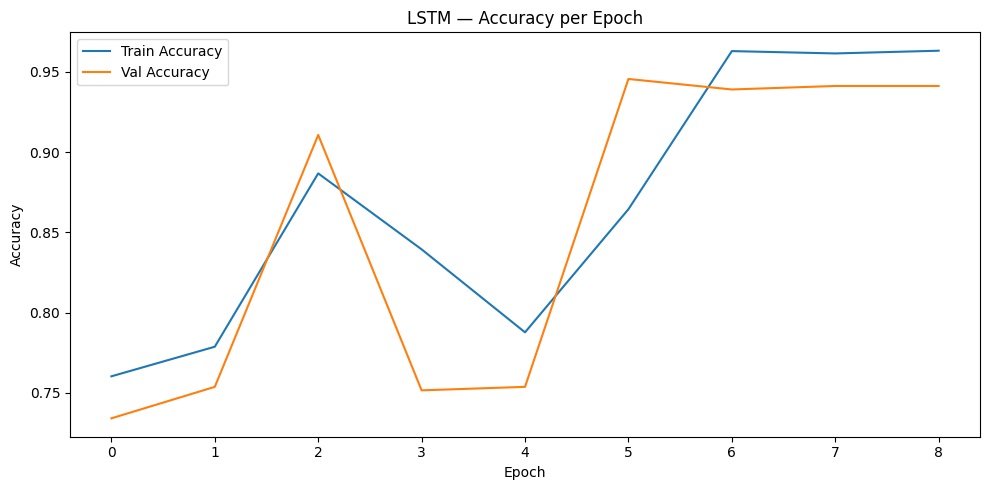

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['accuracy'], label='Train Accuracy')
ax.plot(history.history['val_accuracy'], label='Val Accuracy')
ax.set_title('LSTM — Accuracy per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig('lstm_training_history.png')
plt.show()